In [5]:
import os
import shutil
import tkinter as tk
from tkinter import filedialog
import tensorflow as tf

# 1. Folder Selection
print("📂 Aik window khuli hogi, apna woh folder select karein jahan asli images (cat.0, dog.0 etc.) padi hain...")
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)
source_dir = filedialog.askdirectory(title="Select Correct Image Folder")

print(f"✅ Selected Path: {source_dir}")

if source_dir:
    # Check karein ke folder mein files hain ya nahi
    all_files = os.listdir(source_dir)
    print(f"📁 Is folder mein kul {len(all_files)} files hain.")
    
    cat_files = [f for f in all_files if "cat" in f.lower()]
    dog_files = [f for f in all_files if "dog" in f.lower()]
    
    print(f"🐱 'Cat' wali files mili: {len(cat_files)}")
    print(f"🐶 'Dog' wali files mili: {len(dog_files)}")
    
    if len(cat_files) > 0 and len(dog_files) > 0:
        base_dir = "dataset_modern"
        train_cats = os.path.join(base_dir, 'train', 'cats')
        train_dogs = os.path.join(base_dir, 'train', 'dogs')
        val_cats = os.path.join(base_dir, 'validation', 'cats')
        val_dogs = os.path.join(base_dir, 'validation', 'dogs')

        os.makedirs(train_cats, exist_ok=True)
        os.makedirs(train_dogs, exist_ok=True)
        os.makedirs(val_cats, exist_ok=True)
        os.makedirs(val_dogs, exist_ok=True)

        # Agar folders pehle se khali hain toh copy karein
        if len(os.listdir(train_cats)) == 0:
            print("🔄 Files copy aur split ki ja rahi hain...")
            split_cat = int(len(cat_files) * 0.8)
            split_dog = int(len(dog_files) * 0.8)
            
            for f in cat_files[:split_cat]:
                shutil.copy(os.path.join(source_dir, f), os.path.join(train_cats, f))
            for f in cat_files[split_cat:]:
                shutil.copy(os.path.join(source_dir, f), os.path.join(val_cats, f))
                
            for f in dog_files[:split_dog]:
                shutil.copy(os.path.join(source_dir, f), os.path.join(train_dogs, f))
            for f in dog_files[split_dog:]:
                shutil.copy(os.path.join(source_dir, f), os.path.join(val_dogs, f))
            print("✅ Sorting mukammal ho gayi!")
        else:
            print("✅ Folders pehle se ready hain!")

        # TensorFlow Dataset Loading
        train_dir = os.path.join(base_dir, 'train')
        val_dir = os.path.join(base_dir, 'validation')

        print("📂 Loading datasets into TensorFlow...")
        train_dataset = tf.keras.utils.image_dataset_from_directory(
            train_dir, image_size=(150, 150), batch_size=32, label_mode='binary'
        )
        val_dataset = tf.keras.utils.image_dataset_from_directory(
            val_dir, image_size=(150, 150), batch_size=32, label_mode='binary'
        )

        # Optimization
        AUTOTUNE = tf.data.AUTOTUNE
        train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
        val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

        print("✨ Zabardast! Datasets successfully load aur optimize ho chuki hain!")
    else:
        print("❌ ERROR: Is folder mein 'cat' ya 'dog' naam ki koi file nahi mili! Baraye meharbani sahi folder select karein.")
else:
    print("❌ Aapne koi folder select nahi kiya.")

📂 Aik window khuli hogi, apna woh folder select karein jahan asli images (cat.0, dog.0 etc.) padi hain...
✅ Selected Path: C:/Users/short/Downloads/cn/Asirra_ cat vs dogs
📁 Is folder mein kul 2200 files hain.
🐱 'Cat' wali files mili: 1100
🐶 'Dog' wali files mili: 1100
🔄 Files copy aur split ki ja rahi hain...
✅ Sorting mukammal ho gayi!
📂 Loading datasets into TensorFlow...
Found 880 files belonging to 2 classes.
Found 220 files belonging to 2 classes.
✨ Zabardast! Datasets successfully load aur optimize ho chuki hain!


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, 
    RandomFlip, RandomRotation, RandomZoom, Rescaling
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Modern CNN Model with Data Augmentation
model = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
    
    Rescaling(1./255, input_shape=(150, 150, 3)),
    
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Smart Training Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.00001)
]

print("🚀 Model training shuru ho rahi hai...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=callbacks
)
print("🎉 Training mukammal ho gayi!")

🚀 Model training shuru ho rahi hai...
Epoch 1/10


C:\Users\short\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\short\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


28/28 ━━━━━━━━━━━━━━━━━━━━ 32s 795ms/step - accuracy: 0.5182 - loss: 0.7507 - val_accuracy: 0.5091 - val_loss: 0.6902 - learning_rate: 0.0010
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 28s 991ms/step - accuracy: 0.5568 - loss: 0.6921 - val_accuracy: 0.6091 - val_loss: 0.6860 - learning_rate: 0.0010
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 23s 837ms/step - accuracy: 0.5648 - loss: 0.6875 - val_accuracy: 0.6364 - val_loss: 0.6723 - learning_rate: 0.0010
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 688ms/step - accuracy: 0.5727 - loss: 0.6812 - val_accuracy: 0.6500 - val_loss: 0.6477 - learning_rate: 0.0010
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 652ms/step - accuracy: 0.6136 - loss: 0.6741 - val_accuracy: 0.5682 - val_loss: 0.6744 - learning_rate: 0.0010
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 670ms/step - accuracy: 0.6239 - loss: 0.6577 - val_accuracy: 0.6273 - val_loss: 0.6409 - learning_rate: 0.0010
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 635ms/step - accuracy: 0.6557 - loss: 0.6548 - val_

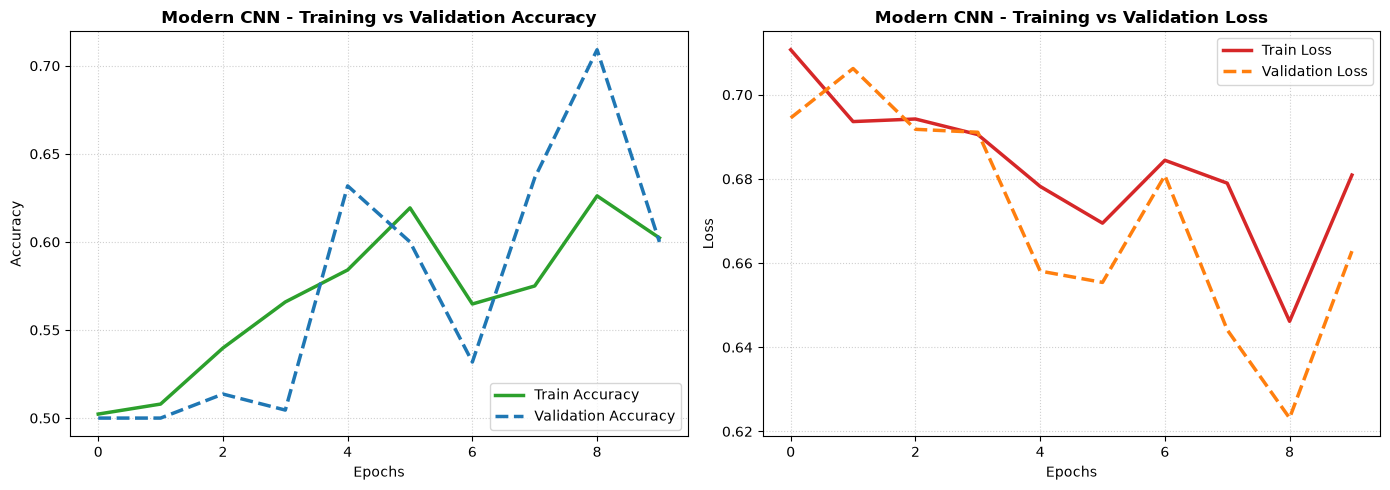

📊 Generating Confusion Matrix and Report...


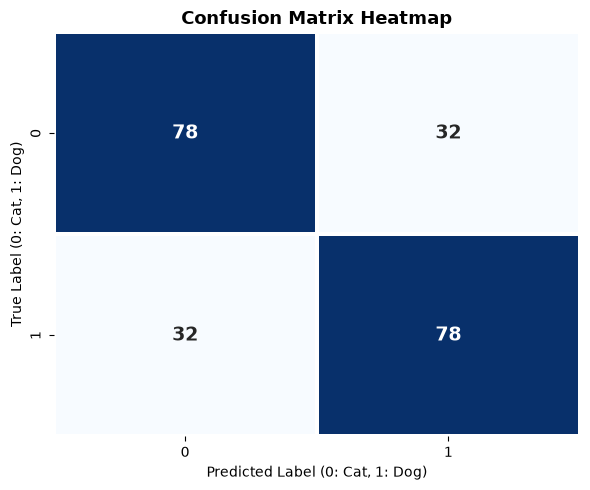


Detailed Classification Report:
              precision    recall  f1-score   support

     Cat (0)       0.71      0.71      0.71       110
     Dog (1)       0.71      0.71      0.71       110

    accuracy                           0.71       220
   macro avg       0.71      0.71      0.71       220
weighted avg       0.71      0.71      0.71       220



In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Styled Accuracy & Loss Graphs
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2.5, color='#2ca02c')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2.5, color='#1f77b4', linestyle='--')
plt.title('Modern CNN - Training vs Validation Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2.5, color='#d62728')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2.5, color='#ff7f0e', linestyle='--')
plt.title('Modern CNN - Training vs Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 2. Confusion Matrix Heatmap
print("📊 Generating Confusion Matrix and Report...")
y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model.predict(images, verbose=0)
    preds = (preds >= 0.5).astype(int)
    y_true.extend(labels.numpy().flatten())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={"size": 14, "weight": "bold"}, linewidths=1.5, linecolor='white')
plt.title('Confusion Matrix Heatmap', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label (0: Cat, 1: Dog)', fontsize=10)
plt.ylabel('True Label (0: Cat, 1: Dog)', fontsize=10)
plt.tight_layout()
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Cat (0)', 'Dog (1)']))